<a href="https://colab.research.google.com/github/HappyRF/Campus-Energy-Consumption-Analytics-Mini-Project/blob/main/Campus_Energy_Consumption_Analysis_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Campus Energy Consumption Analytics

*Project Description*

- A data analytics project that analyzes campus electricity consumption patterns across buildings to identify energy-saving opportunities, reduce costs, and improve sustainability.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/HappyRF/Campus-Energy-Consumption-Analytics-Mini-Project/refs/heads/main/Campus_Energy_Consumption_Dataset.csv")
df

,Date,Day,Building_Name,Building_Type,Time_Slot,Occupancy_Count,Electricity_Consumed_kWh,Peak_Demand_kW,Temperature_C,Renewable_Energy_kWh,Grid_Energy_kWh,Cost_Per_kWh,Total_Cost_INR,Carbon_Emission_kg,Holiday_Flag
0,2025-01-01,Wednesday,CSE Block,Academic,Morning,215,228,57.0,30,25,203,8,1824,142.1,No
1,2025-01-01,Wednesday,CSE Block,Academic,Afternoon,334,291,72.8,30,51,240,8,2328,168.0,No
2,2025-01-01,Wednesday,CSE Block,Academic,Evening,438,211,52.8,30,45,166,8,1688,116.2,No
3,2025-01-01,Wednesday,CSE Block,Academic,Night,406,97,24.2,30,0,97,8,776,67.9,No
4,2025-01-01,Wednesday,ECE Block,Academic,Morning,217,229,57.2,30,20,209,8,1832,146.3,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14595,2025-12-31,Wednesday,Hostel B,Hostel,Night,457,107,26.8,25,0,107,8,856,74.9,No
14596,2025-12-31,Wednesday,Cafeteria,Cafeteria,Morning,297,187,46.8,25,29,158,8,1496,110.6,No
14597,2025-12-31,Wednesday,Cafeteria,Cafeteria,Afternoon,324,210,52.5,25,24,186,8,1680,130.2,No
14598,2025-12-31,Wednesday,Cafeteria,Cafeteria,Evening,267,180,45.0,25,36,144,8,1440,100.8,No


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14600 entries, 0 to 14599
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Date                      14600 non-null  object 
 1   Day                       14600 non-null  object 
 2   Building_Name             14600 non-null  object 
 3   Building_Type             14600 non-null  object 
 4   Time_Slot                 14600 non-null  object 
 5   Occupancy_Count           14600 non-null  int64  
 6   Electricity_Consumed_kWh  14600 non-null  int64  
 7   Peak_Demand_kW            14600 non-null  float64
 8   Temperature_C             14600 non-null  int64  
 9   Renewable_Energy_kWh      14600 non-null  int64  
 10  Grid_Energy_kWh           14600 non-null  int64  
 11  Cost_Per_kWh              14600 non-null  int64  
 12  Total_Cost_INR            14600 non-null  int64  
 13  Carbon_Emission_kg        14600 non-null  float64
 14  Holida

In [23]:
df.describe()

,Occupancy_Count,Electricity_Consumed_kWh,Peak_Demand_kW,Temperature_C,Renewable_Energy_kWh,Grid_Energy_kWh,Cost_Per_kWh,Total_Cost_INR,Carbon_Emission_kg
count,14600.000000,14600.000000,14600.000000,14600.000000,14600.000000,14600.000000,14600.0,14600.00000,14600.000000
mean,229.447055,220.516986,55.128747,30.610959,28.888699,191.628288,8.0,1764.13589,134.139801
std,138.029130,115.881721,28.970901,4.286716,23.738025,95.821169,0.0,927.05377,67.074818
min,9.000000,36.000000,9.000000,24.000000,0.000000,36.000000,8.0,288.00000,25.200000
25%,109.000000,144.000000,36.000000,27.000000,6.750000,128.000000,8.0,1152.00000,89.600000
50%,203.000000,199.000000,49.800000,31.000000,28.000000,172.000000,8.0,1592.00000,120.400000
75%,336.000000,280.000000,70.000000,34.000000,41.000000,237.000000,8.0,2240.00000,165.900000
max,550.000000,615.000000,153.800000,38.000000,135.000000,565.000000,8.0,4920.00000,395.500000


In [3]:
df.columns

Index(['Date', 'Day', 'Building_Name', 'Building_Type', 'Time_Slot',
       'Occupancy_Count', 'Electricity_Consumed_kWh', 'Peak_Demand_kW',
       'Temperature_C', 'Renewable_Energy_kWh', 'Grid_Energy_kWh',
       'Cost_Per_kWh', 'Total_Cost_INR', 'Carbon_Emission_kg', 'Holiday_Flag'],
      dtype='object')

#Questions to answer
1. Which building consumes the most energy?

In [12]:
building_energy = df.groupby('Building_Name')['Electricity_Consumed_kWh'].sum().sort_values(ascending=False)
highest_building = building_energy.idxmax()
highest_energy = building_energy.max()

building_energy

,Electricity_Consumed_kWh
Building_Name,
Mechanical Lab,597810
Hostel A,426552
Hostel B,414680
CSE Block,296209
ECE Block,283067
EEE Block,276071
Civil Block,257377
Library,244228
Cafeteria,231416


In [41]:
f"The building with the highest consumption is {highest_building}."

'The building with the highest consumption is Mechanical Lab.'

In [42]:
f"Total Energy consumed is {highest_energy} kWh."

'Total Energy consumed is 597810 kWh.'

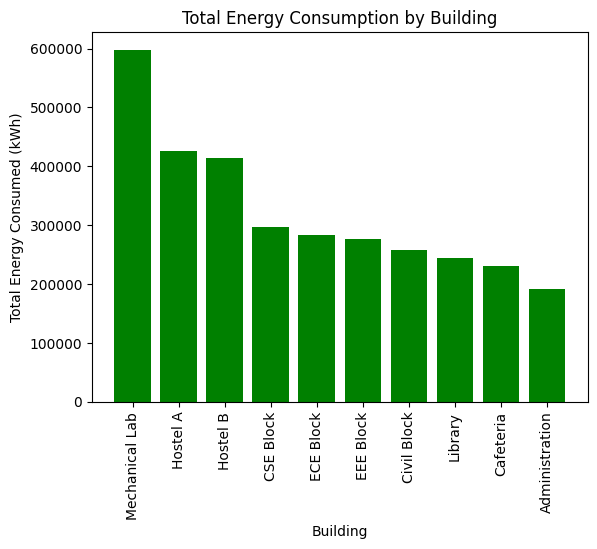

In [21]:
plt.bar(
    building_energy.index,
    building_energy.values,
    color='green'
)
plt.title("Total Energy Consumption by Building")
plt.xlabel('Building')
plt.xticks(rotation=90)
plt.ylabel('Total Energy Consumed (kWh)')
plt.show()

2. Which time of day has the highest usage?

In [35]:
time_energy = df.groupby('Time_Slot')['Electricity_Consumed_kWh'].sum().sort_values(ascending=False)

highest_time = time_energy.idxmax()
highest_usage = time_energy.max()

time_energy

,Electricity_Consumed_kWh
Time_Slot,
Afternoon,1154300
Morning,893738
Evening,804922
Night,366588


In [39]:
f"The highest usage time of the day is {highest_time}."

'The highest usage time of the day is Afternoon.'

In [38]:
f"Energy consumed during {highest_time} is {highest_usage} kWh."

'Energy consumed during Afternoon is 1154300 kWh.'

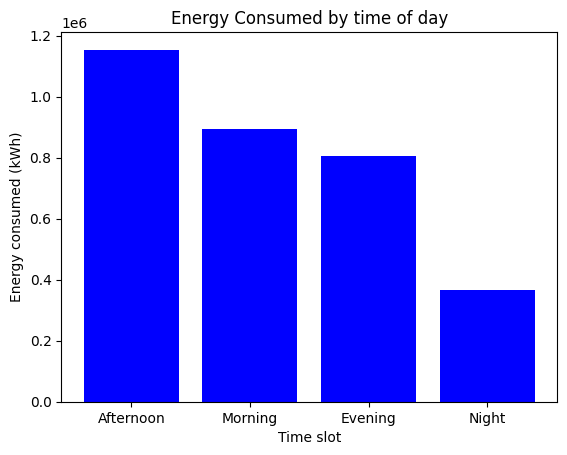

In [43]:
plt.bar(time_energy.index, time_energy.values, color='blue')
plt.title("Energy Consumed by time of day")
plt.xlabel("Time slot")
plt.ylabel("Energy consumed (kWh)")
plt.show()

([<matplotlib.patches.Wedge at 0x7ae2de409400>,
 [Text(0.5159488517119191, 1.083419024393218, 'Afternoon'),
  Text(-1.199830797769938, 0.020150849181966447, 'Morning'),
  Text(0.08386028601327318, -1.197066185484233, 'Evening'),
  Text(1.1240406129443004, -0.4201579470292115, 'Night')],
 [Text(0.3009701634986194, 0.6319944308960439, '35.9%'),
  Text(-0.6999012986991304, 0.011754662022813759, '27.8%'),
  Text(0.04891850017440935, -0.698288608199136, '25.0%'),
  Text(0.6556903575508419, -0.24509213576704, '11.4%')])

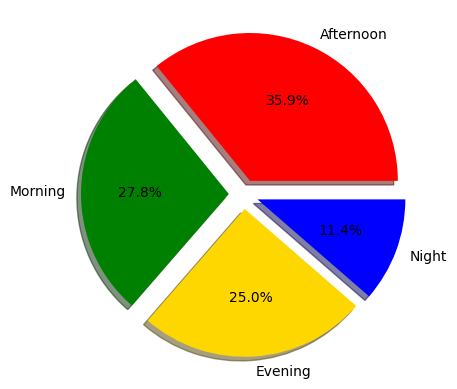

In [54]:
colors=['red','green','gold','blue']
explode=(0.1,0.1,0.1,0.1)
plt.pie(
    time_energy.values,
    labels=time_energy.index,
    autopct='%1.1f%%',
    explode = explode,
    colors = colors,
    shadow = True
)


3. Which days consume more electricity?

In [61]:
day_energy = df.groupby("Day")['Electricity_Consumed_kWh'].sum()

highest_day = day_energy.idxmax()
day_usage = day_energy.max()

day_energy

,Electricity_Consumed_kWh
Day,
Friday,457341
Monday,458240
Saturday,458234
Sunday,460051
Thursday,459143
Tuesday,458284
Wednesday,468255


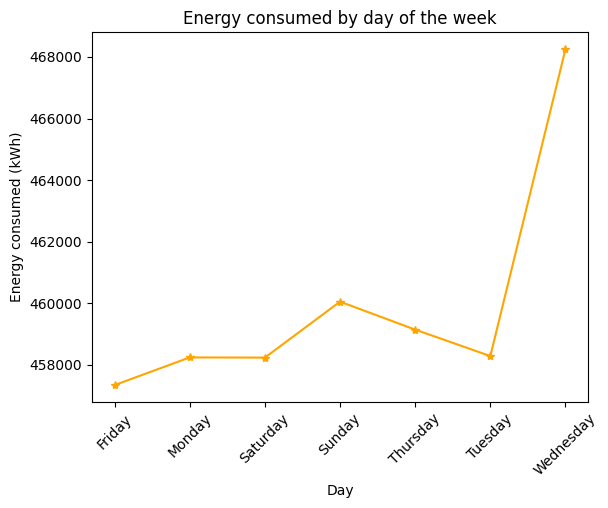

In [64]:
plt.plot(day_energy.index,day_energy.values,color="Orange", marker = '*')
plt.title("Energy consumed by day of the week")
plt.xlabel("Day")
plt.xticks(rotation=45)
plt.ylabel("Energy consumed (kWh)")
plt.show()

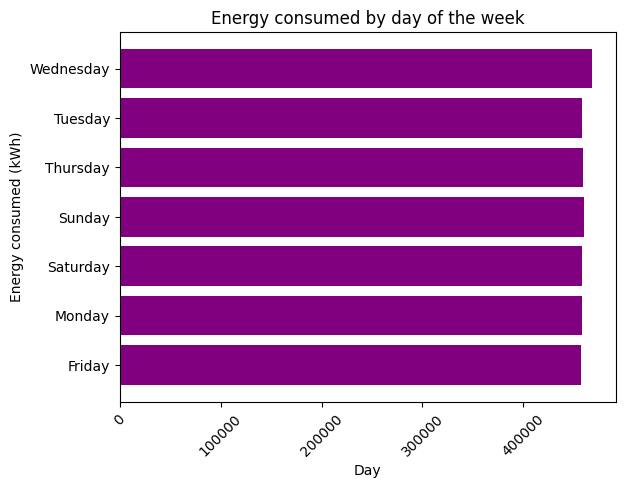

In [67]:
plt.barh(day_energy.index,day_energy.values,color="purple")
plt.title("Energy consumed by day of the week")
plt.xlabel("Day")
plt.xticks(rotation=45)
plt.ylabel("Energy consumed (kWh)")
plt.show()

4. How can energy wastage be reduced?

In [72]:
#The total energy wasted can be estimated by calculating energy per occupant
df['Energy_Per_Occupant'] = df['Electricity_Consumed_kWh']/df['Occupancy_Count']
wastage = df.sort_values(by='Energy_Per_Occupant', ascending = False)

wastage[['Building_Name',
               'Time_Slot',
               'Occupancy_Count',
               'Electricity_Consumed_kWh',
               'Energy_Per_Occupant']].head(10)

,Building_Name,Time_Slot,Occupancy_Count,Electricity_Consumed_kWh,Energy_Per_Occupant
9133,Mechanical Lab,Afternoon,28,611,21.821429
1585,Administration,Afternoon,9,196,21.777778
12453,Mechanical Lab,Afternoon,27,581,21.518519
7173,Mechanical Lab,Afternoon,27,570,21.111111
2653,Mechanical Lab,Afternoon,27,569,21.074074
173,Mechanical Lab,Afternoon,27,568,21.037037
13853,Mechanical Lab,Afternoon,27,567,21.000000
10213,Mechanical Lab,Afternoon,29,605,20.862069
5453,Mechanical Lab,Afternoon,30,613,20.433333
3825,Administration,Afternoon,9,182,20.222222


In [79]:
#Renewable Percentage in each Building

building_renewable = (df.groupby('Building_Name')[['Renewable_Energy_kWh', 'Electricity_Consumed_kWh']].sum())

building_renewable['Renewable_Percentage'] = (building_renewable['Renewable_Energy_kWh'] / building_renewable['Electricity_Consumed_kWh']) * 100

building_renewable['Renewable_Percentage'].sort_values(ascending = False)

,Renewable_Percentage
Building_Name,
Mechanical Lab,13.335508
Hostel B,13.233095
Hostel A,13.096879
Library,13.034951
CSE Block,13.024250
Administration,13.020329
Civil Block,13.015538
ECE Block,12.967955
Cafeteria,12.945950


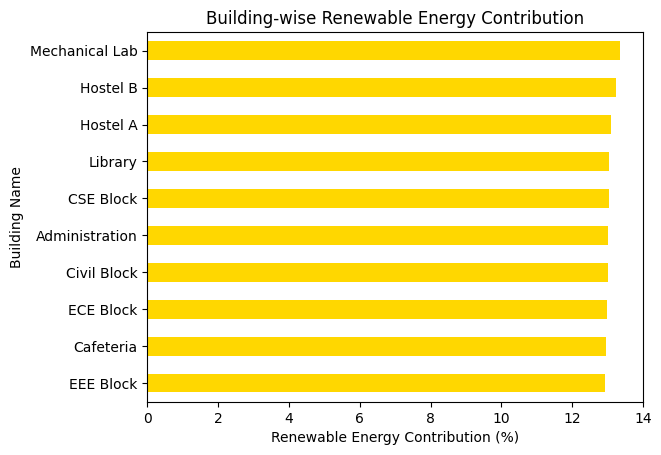

In [92]:
building_renewable['Renewable_Percentage'].sort_values().plot(kind='barh',color = 'gold')

plt.xlabel('Renewable Energy Contribution (%)')
plt.ylabel('Building Name')
plt.title('Building-wise Renewable Energy Contribution')
plt.show()

In [93]:
#Total energy and cost that can be saved

total_energy = df['Electricity_Consumed_kWh'].sum()
total_cost = df['Total_Cost_INR'].sum()

energy_saved = total_energy * 0.10
cost_saved = total_cost * 0.10

print(f"Potential Energy Saved: {energy_saved:.2f} kWh")
print(f"Potential Cost Saved: ₹{cost_saved:.2f}")

Potential Energy Saved: 321954.80 kWh
Potential Cost Saved: ₹2575638.40


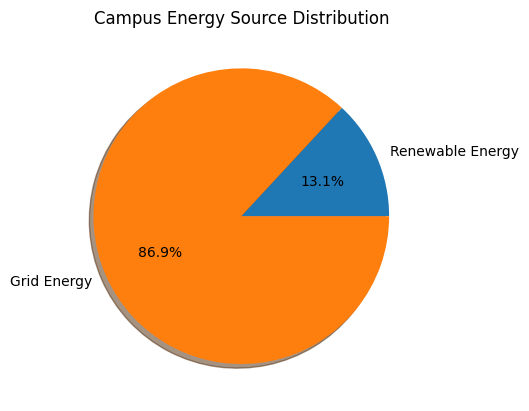

In [94]:
renewable = df['Renewable_Energy_kWh'].sum()
grid = df['Grid_Energy_kWh'].sum()

plt.pie(
    [renewable, grid],
    labels=['Renewable Energy', 'Grid Energy'],
    autopct='%1.1f%%',
    shadow = True
)
plt.title('Campus Energy Source Distribution')
plt.show()

#Observations:

- The Mechanical lab is found to be the highest energy-consuming building on campus, indicating significant electricity usage by laboratory equipment and machinary.

- The Afternoon time slot records the highest electricity consumption across most buildings.

- Here, more occupancy count leads to more energy demand.

- Renewable energy contributes only a small percentage of total energy consumption, showing significant dependence on grid electricity.

- Out of all the days of the week, Wednesday records the highest electricity consumption.

#Recommendations:

- Replace conventional lighting systems with energy-efficient LED lighting throughout the campus.

- Optimize air conditioning usage by maintaining recommended temperature settings (24-26°C).

- Ensure that computers, projectors, laboratory equipment, and other devices are switched off when not in use.

- Conduct regular energy audits to identify inefficient equipment and areas of excessive consumption.

- Increase the installation and utilization of solar panels to reduce dependency on grid electricity.

- Implement smart energy monitoring systems to track real-time electricity consumption.

- Create awareness programs for students, faculty, and staff regarding energy conservation practices.

- Increase renewable energy adoption to lower carbon emissions and support campus sustainability initiatives.